In [7]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits
from craft.craftcor import MiriadGainSolutions
import glob
from craco.search_pipeline import location2pix, get_grid_lut_from_plan, grid_candidates,wait_for_starts,waitall,print_candidates
from craco.search_pipeline import NBINARY_POINT_FDMTIN, VisSource
import craco
import craco.search_pipeline
from craco.pyxrtutil import *
import craft.craco_plan

from craft import uvfits

from craft.craco_plan import PipelinePlan
from craft.craco import printstats,bl2ant
import logging
import time

%matplotlib notebook
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
cd /data/craco/ban115/craco-python/notebooks/data/SB43128/run3


/data/craco/ban115/craco-python/notebooks/data/SB43128/run3


In [9]:
ls *.uvfits

SB43128_run3_v2_beam00_beam00.uvfits  SB43128_run3_v2_beam00.uvfits


In [25]:
fits='SB43128_run3_v2_beam00.uvfits'
f = uvfits.open(fits)
f.set_flagants([23])
values = craco.search_pipeline.get_parser().parse_args(f'--ndm 2 --uv {fits}'.split())
plan = PipelinePlan(f, values)

/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=259.0 1-3 uvpix=(0, 254)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=260.0 1-4 uvpix=(2, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(15, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(16, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=

Upper registers [(2, 1), (3, 1), (14, 1), (15, 1), (166, 1), (167, 1), (168, 1), (169, 1), (170, 1), (236, 1), (237, 1), (241, 1), (243, 1), (248, 1), (249, 1), (255, 1), (33, 2), (34, 2), (35, 2), (46, 2), (51, 2), (52, 2), (53, 2), (54, 2), (206, 2), (207, 2), (208, 2), (209, 2), (224, 2), (225, 2), (226, 2), (235, 2)]
Lower registers [(1, 2), (2, 3), (2, 4), (1, 5), (4, 5), (4, 7), (5, 8), (6, 8), (5, 9), (7, 9), (8, 9), (4, 10), (6, 10), (8, 10), (1, 11), (5, 11), (6, 11), (8, 11), (9, 11), (1, 12), (5, 12), (7, 12), (7, 13), (12, 14), (13, 14), (12, 15), (13, 15), (7, 16), (14, 16), (15, 16), (7, 17), (15, 17)]


In [27]:
xclbin = '/data/craco/ban115/builds/binary_container_fe3fef0d.xclbin'
device = pyxrt.device(1)
xbin = pyxrt.xclbin(xclbin)
uuid = device.load_xclbin(xbin)
alloc_device_only=True
p = craco.search_pipeline.Pipeline(device, xbin, plan, alloc_device_only)

Kernel krnl_ddgrid_reader_4cu:krnl_ddgrid_reader_4cu_1 has groups
GID=0=32
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=15
Kernel krnl_grid_4cu:krnl_grid_4cu_1 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=6
Kernel krnl_grid_4cu:krnl_grid_4cu_2 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=7
Kernel krnl_grid_4cu:krnl_grid_4cu_3 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=20
Kernel krnl_grid_4cu:krnl_grid_4cu_4 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=21
Kernel fft2d:fft2d_1 has groups
Kernel fft2d:fft2d_2 has groups
Kernel fft2d:fft2d_3 has groups
Kernel fft2d:fft2d_4 has groups
Kernel krnl_boxc_4cu:krnl_boxc_4cu_1 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=54
GID=4=54
GID=5=4
Kernel fdmt_tunable_c32:fdmt_tunable_c32_1 has groups
GID=0=52
GID=1=32
GID=2=53
GID=3=53
GID=4=14
Allocated 360428 bytes flags=flags.normal groupid=6 address=0x60000000
Allocated 360428 bytes flags=flags.normal groupid=7 address=0x70000000
Allo

In [28]:
for blkd in f.time_blocks(256):
    blk = craft.craco.bl2array(blkd)
    break

In [29]:
blk.shape

(406, 288, 2, 256)

In [30]:
blk.dtype

dtype('complex64')

In [31]:
type(blk)

numpy.ma.core.MaskedArray

<IPython.core.display.Javascript object>


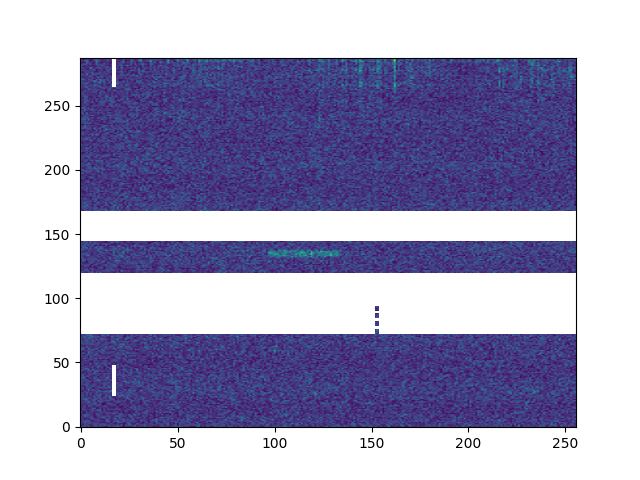

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [32]:
figure()
imgd = abs(blk[0,:,1,:])
                          
imshow(imgd, origin='lower', aspect='auto')

In [33]:
blk.shape

(406, 288, 2, 256)

In [34]:
from craco import calibration
gains = calibration.load_gains('SB43128_run3_v2_beam00.uvfits.mir')
log.info('Loaded calibration gains %s from calfile %s', gains.shape,'run3.mir')
p.set_calibration_gains(gains)


Using MIRIAD bandpass solutions


/data/craco/ban115/craft-github/src/craft/craftcor.py:643: RuntimeWarning: divide by zero encountered in true_divide
  g = 1/np.conj(g)
/data/craco/ban115/craft-github/src/craft/craftcor.py:643: RuntimeWarning: invalid value encountered in true_divide
  g = 1/np.conj(g)


<IPython.core.display.Javascript object>


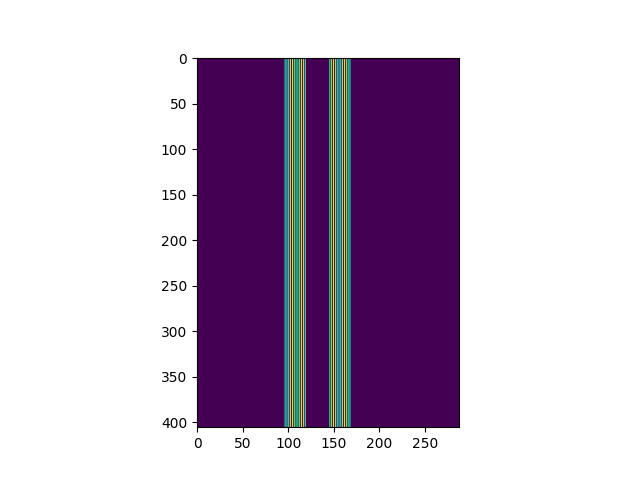

In [35]:
figure()
imshow(p.solarray.mask[:,:,0,0])

In [55]:
blk_cal = p.calibrate_input(blk)

In [56]:
blk_cal.shape

(406, 288, 256)

In [57]:
blk_cal.dtype

dtype('complex128')

<IPython.core.display.Javascript object>


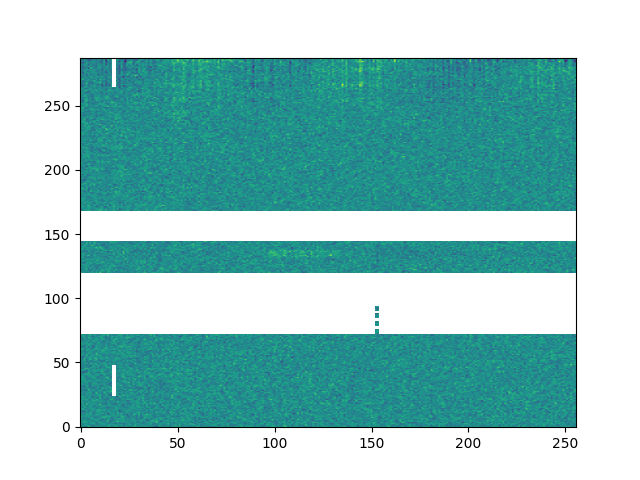

In [58]:
figure()
imshow((blk_cal[0,:,:]).real, aspect='auto', origin='lower')

In [41]:
assert np.all(blk_cal.data.real[blk_cal.mask] == 0+0j)

In [42]:
p.solarray.shape

(406, 288, 2, 1)

In [43]:
blk_ac = p.solarray*blk

In [44]:
blk_ac.shape

(406, 288, 2, 256)

<IPython.core.display.Javascript object>


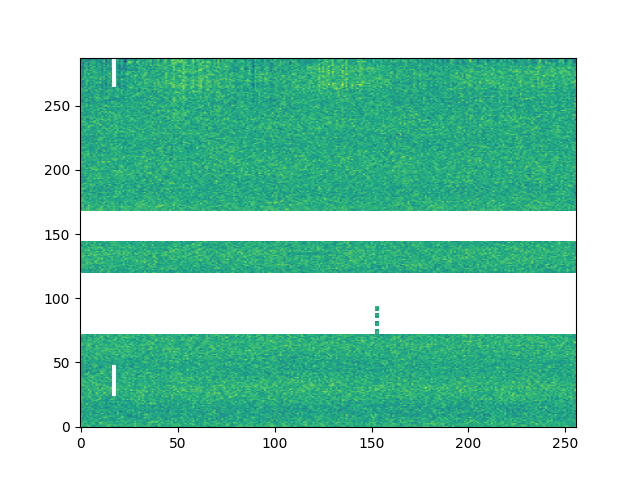

In [47]:
figure()
imshow(blk_ac[0,:,0,:].real, aspect='auto', origin='lower')

In [49]:
blk_sub = blk_ac - blk_ac.mean(axis=-1, keepdims=True)

<IPython.core.display.Javascript object>


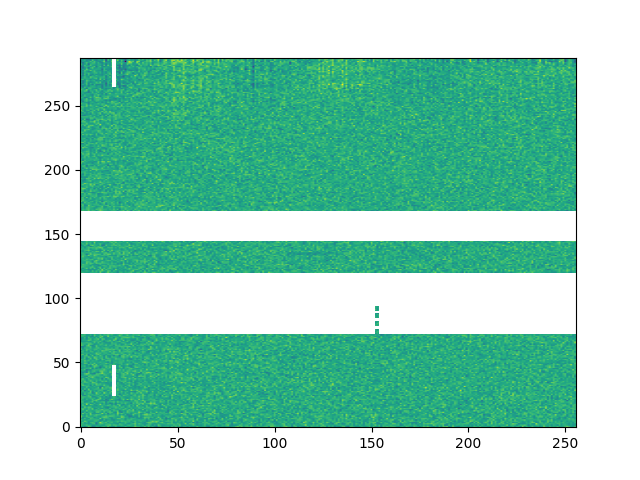

In [50]:
figure()
imshow(blk_sub[0,:,0,:].real, aspect='auto', origin='lower')

In [51]:
blk_sub[0,...].mean()

(-2.469953618089542e-07-5.5716059770715824e-08j)

In [52]:
blk_polsum = blk_sub.mean(axis=2)

<IPython.core.display.Javascript object>


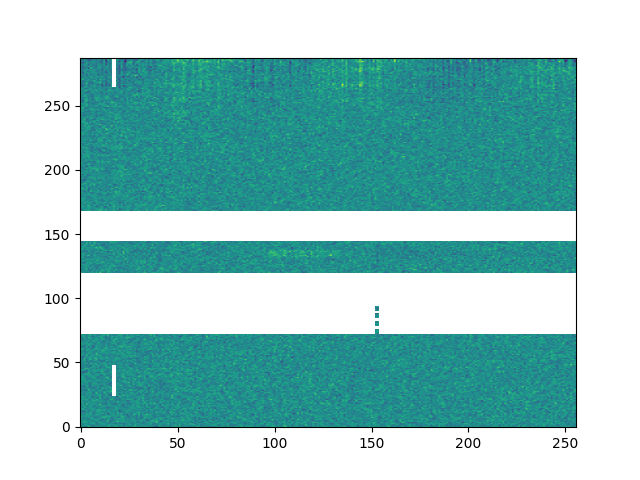

In [54]:
figure()
imshow(blk_polsum[0,:,:].real, aspect='auto', origin='lower')

In [ ]:
blk_sub[0,...].real.std()

In [ ]:
blk.shape

In [ ]:
blk_cal[0,...].mean()

In [ ]:
(blk_cal[0,...] - blk_cal[0,...].mean()).mean()

In [ ]:
blk_cal.real.std()

In [ ]:
p.solarray.shape

In [10]:
b0 = np.load('input_iblk0.npy', allow_pickle=True)

In [11]:
b0.shape

(406, 288, 256)

<IPython.core.display.Javascript object>


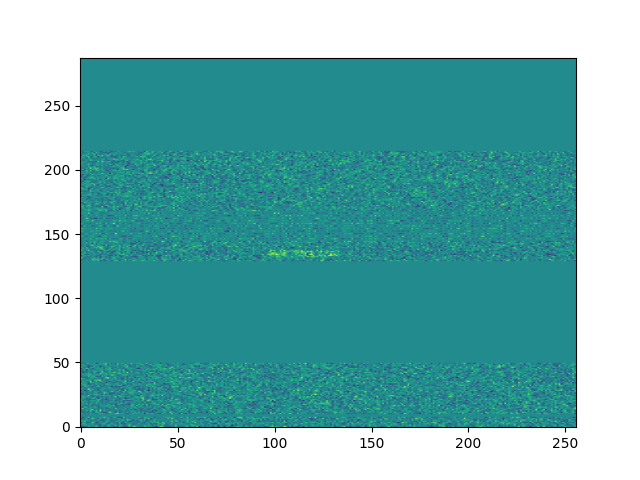

In [14]:
figure()
imshow(b0[0,:,:].data.real, aspect='auto', origin='lower')

In [13]:
b0[0,-10:-1,0]

masked_array(data=[--, --, --, --, --, --, --, --, --],
             mask=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True],
       fill_value=(1e+20+0j),
            dtype=complex128)

In [15]:
N = 256
d = np.zeros((N,N), dtype=np.complex64)

In [16]:
%timeit np.fft.fft2(d)

1.13 ms ± 14.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
